In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mesa_reader as mr

import sys
sys.path.append('..')
from src.util import MESA_DATA_DIR, DATA_DIR

In [2]:
plt.style.use('plotstyle.mplstyle')

In [3]:
def get_model_folder(model_id, verbose=True):
    """Finds model folder given its id."""
    matches = list(PROJECT_FOLDER.glob(f'{model_id}*'))
    
    if len(matches) > 1:
        if verbose:
            print('\n'.join((
                f'Multiple matches for id {model_id} found in {PROJECT_FOLDER}:',
                *[str(match) for match in matches]
            )))
        return
    elif len(matches) != 0:
        match = matches[0]
        if verbose:
            print(f'Found match {match}')
        return match
    else:
        if verbose:
            print(f'No matches found in {PROJECT_FOLDER}')
        return           
    
def get_model_dict(grid_folder):
    """Given a model folder, loads the paths of specific stars into a 
    m1, p_orb dictionary."""
    d = dict()
    for model_folder in grid_folder.glob('m*_p*_w*'):
        if model_folder.suffix == '.log':
            continue
        m, p, w = model_folder.name.replace('d', 'e').split('_')
        w = float(w.lstrip('w'))
        p = f'{float(p.lstrip("p")):.2f}'      
        m = f'{float(m.lstrip("m")):.1f}'
        
        if m not in d.keys():
            d[m] = dict()
        d[m][p] = model_folder
    return d

In [4]:
PROJECT_BASE = MESA_DATA_DIR / '00_fiducial'

# Each entry: { label used in all_model_dicts : (variable suffix, folder name) }
metallicity_map = {
  #  '0.0005': ('0005zsun', '0000_ZdivZsun_5d-03'),
  #  '0.001':  ('001zsun',  '0001_ZdivZsun_1d-02'),
    '0.02':  ('002zsun',  '0002_ZdivZsun_2d-02'),
    '0.04':  ('004zsun',  '0003_ZdivZsun_4d-02'),
    '0.08':  ('008zsun',  '0004_ZdivZsun_8d-02'),
    '0.1':   ('01zsun',   '0005_ZdivZsun_1d-01'),
    '0.2':   ('02zsun',   '0006_ZdivZsun_2d-01'),
    '0.3':   ('03zsun',   '0007_ZdivZsun_3d-01'),
    '0.4':   ('04zsun',   '0008_ZdivZsun_4d-01'),
}

# initialize container for final dict
all_model_dicts = {}

for z_label, (suffix, folder_name) in metallicity_map.items():
    PROJECT_FOLDER = PROJECT_BASE / folder_name

    model_ids = np.arange(1, 25, 1)
    model_ids = np.array([f'{id:03d}' for id in model_ids])
    model_folders = np.array([get_model_folder(id) for id in model_ids])
    model_dicts = np.array([get_model_dict(folder) for folder in model_folders])
    model_labels = np.array([f'${float(id):0f}\\,\\mathrm{{M}}_\\odot$' for id in model_ids])

    # create a variable named model_dicts_XXXzsun dynamically
    globals()[f'model_dicts_{suffix}'] = model_dicts

    # add entry to final dict (same structure as before)
    all_model_dicts[z_label] = {
    k: v
    for d in model_dicts
    for k, v in d.items()
}



No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00_fiducial/0002_ZdivZsun_2d-02
No matches found in /mnt/home/ldesa/ceph/mesa_che_grids/sse_production/00

AttributeError: 'NoneType' object has no attribute 'glob'

In [5]:
import pandas as pd
core_props_df = pd.read_hdf(DATA_DIR/'00_fiducial_core_props_df.h5')

In [6]:
suc_che_df = core_props_df[(~core_props_df.is_l2of_at_zams) & (core_props_df.is_che) & (~core_props_df.is_crash)]

In [7]:
suc_che_df['z'] = suc_che_df['z_key'].astype(float)

/tmp/ipykernel_771747/2058798488.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  suc_che_df['z'] = suc_che_df['z_key'].astype(float)


In [8]:
list(suc_che_df.columns)

['z_key',
 'm_zams',
 'm_wr0',
 'm_wr1',
 'm_tams',
 'm_tahems',
 'm_cdepl',
 'm_odepl',
 'm_f',
 'm_c_zams',
 'm_c_wr0',
 'm_c_wr1',
 'm_c_tams',
 'm_c_tahems',
 'm_c_cdepl',
 'm_c_odepl',
 'm_c_f',
 'inertia_zams',
 'inertia_wr0',
 'inertia_wr1',
 'inertia_tams',
 'inertia_tahems',
 'inertia_cdepl',
 'inertia_odepl',
 'inertia_f',
 'p_spin_zams',
 'p_spin_wr0',
 'p_spin_wr1',
 'p_spin_tams',
 'p_spin_tahems',
 'p_spin_cdepl',
 'p_spin_odepl',
 'p_spin_f',
 'r_zams',
 'r_wr0',
 'r_wr1',
 'r_tams',
 'r_tahems',
 'r_cdepl',
 'r_odepl',
 'r_f',
 'r_c_zams',
 'r_c_wr0',
 'r_c_wr1',
 'r_c_tams',
 'r_c_tahems',
 'r_c_cdepl',
 'r_c_odepl',
 'r_c_f',
 'log_rho_c_zams',
 'log_rho_c_wr0',
 'log_rho_c_wr1',
 'log_rho_c_tams',
 'log_rho_c_tahems',
 'log_rho_c_cdepl',
 'log_rho_c_odepl',
 'log_rho_c_f',
 'log_j_zams',
 'log_j_wr0',
 'log_j_wr1',
 'log_j_tams',
 'log_j_tahems',
 'log_j_cdepl',
 'log_j_odepl',
 'log_j_f',
 'p_orb_zams',
 'p_orb_wr0',
 'p_orb_wr1',
 'p_orb_tams',
 'p_orb_tahems',
 'p

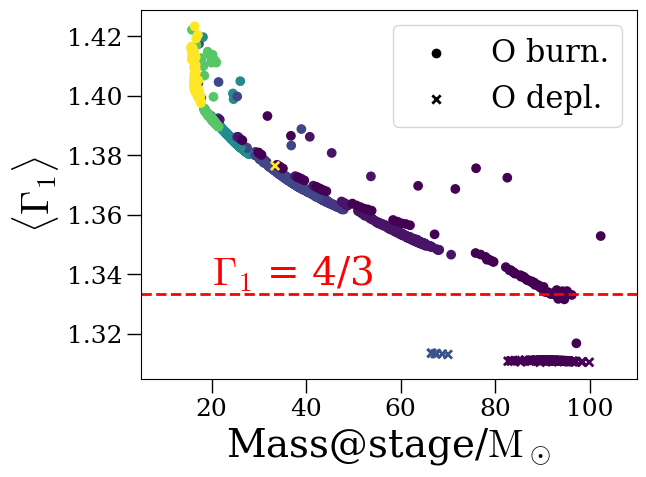

In [9]:
fig, ax = plt.subplots()

df = suc_che_df[~suc_che_df.is_O_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z
)



ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right')

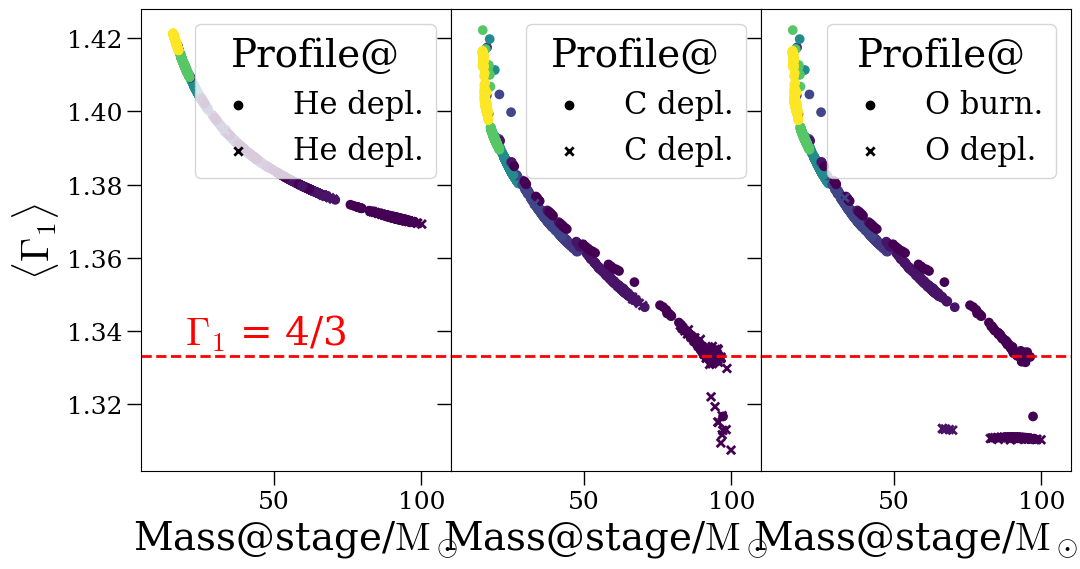

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
fig.subplots_adjust(wspace=0)


ax = axes[0]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_tahems,
    df.gamma1_w_avg_tahems,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')

handles = [
    ax.scatter([], [], marker='o', color='k', label='He depl.'),
    ax.scatter([], [], marker='x', color='k', label='He depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')


ax = axes[1]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)



df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_cdepl,
    df.gamma1_w_avg_cdepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')


ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='C depl.'),
    ax.scatter([], [], marker='x', color='k', label='C depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

ax = axes[2]
df = suc_che_df[~suc_che_df.is_O_depleted & suc_che_df.is_C_depleted]
ax.scatter(
    df.m_f,
    df.gamma1_w_avg_f,
    marker='o',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

df = suc_che_df[suc_che_df.is_O_depleted]
ax.scatter(
    df.m_odepl,
    df.gamma1_w_avg_odepl,
    marker='x',
    c=df.z,
    vmin=0.02,
    vmax=0.4
)

ax.hlines(4/3, 5, 110, colors='r', linestyles='dashed')
#ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

ax.set_xlim(5, 110)
ax.set_xlabel('Mass@stage/$\mathrm{M}_\odot$')


handles = [
    ax.scatter([], [], marker='o', color='k', label='O burn.'),
    ax.scatter([], [], marker='x', color='k', label='O depl.')
]
ax.legend(handles=handles, loc='upper right', title='Profile@')

In [102]:
suc_che_df.columns

Index(['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_cdepl',
       'm_odepl', 'm_f', 'm_c_zams',
       ...
       'is_che', 'is_crit_at_zams', 'is_merger_at_zams', 'is_l2of_at_zams',
       'is_He_depleted', 'is_half_C_depleted', 'is_C_depleted',
       'is_O_depleted', 'is_crash', 'z'],
      dtype='object', length=108)

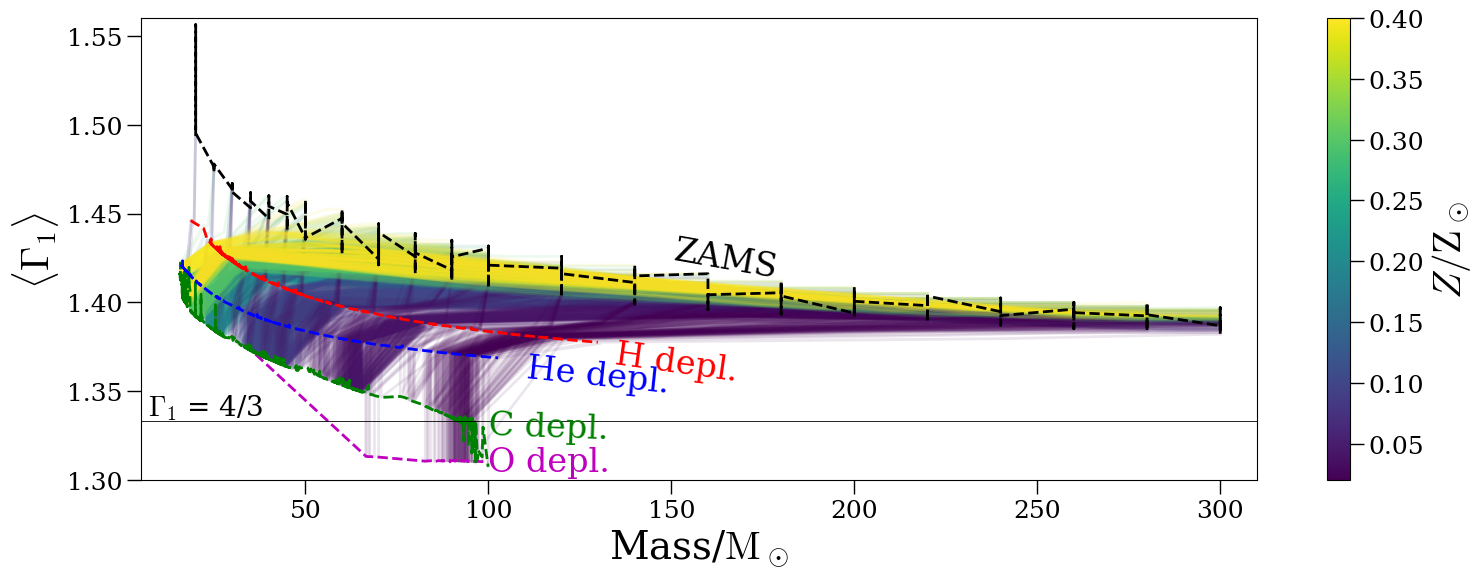

In [12]:
stages = ['zams', 'wr0', 'wr1', 'tams', 'tahems', 'cdepl', 'odepl']

fig, ax = plt.subplots(figsize=(18, 6))

for row in suc_che_df.itertuples():
    m = [getattr(row, 'm_'+stage) for stage in stages]
    z = row.z
    gamma1_w_avg_values = [getattr(row, f'gamma1_w_avg_{stage}') for stage in stages]
    ax.plot(
        m,
        gamma1_w_avg_values,
        marker='none',
        color=plt.cm.viridis((z-0.02)/0.38),
        alpha=0.1
    )
    
all_odepl_df = suc_che_df[suc_che_df.is_O_depleted]
odepl_x = [getattr(row, 'm_odepl') for row in all_odepl_df.itertuples()]
odepl_y = [getattr(row, 'gamma1_w_avg_odepl') for row in all_odepl_df.itertuples()]
sorted_indices = np.argsort(odepl_x)
ax.plot(
    np.array(odepl_x)[sorted_indices],
    np.array(odepl_y)[sorted_indices],
    marker='none',
    color='m',
    linestyle='--',
    label='O depl.'
)

all_cdepl_df = suc_che_df[suc_che_df.is_C_depleted]
cdepl_x = [getattr(row, 'm_cdepl') for row in all_cdepl_df.itertuples()]
cdepl_y = [getattr(row, 'gamma1_w_avg_cdepl') for row in all_cdepl_df.itertuples()]
sorted_indices = np.argsort(cdepl_x)
ax.plot(
    np.array(cdepl_x)[sorted_indices],
    np.array(cdepl_y)[sorted_indices],
    marker='none',
    color='g',
    linestyle='--',
    label='C depl.'
)

all_hedepl_df = suc_che_df[suc_che_df.is_He_depleted]
hedepl_x = [getattr(row, 'm_tahems') for row in all_hedepl_df.itertuples()]
hedepl_y = [getattr(row, 'gamma1_w_avg_tahems') for row in all_hedepl_df.itertuples()]
sorted_indices = np.argsort(hedepl_x)
ax.plot(
    np.array(hedepl_x)[sorted_indices],
    np.array(hedepl_y)[sorted_indices],
    marker='none',
    color='b',
    linestyle='--',
    label='He depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_tams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_tams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='r',
    linestyle='--',
    label='H depl.'
)

all_hdepl_df = suc_che_df[suc_che_df.is_che]
hdepl_x = [getattr(row, 'm_zams') for row in all_hdepl_df.itertuples()]
hdepl_y = [getattr(row, 'gamma1_w_avg_zams') for row in all_hdepl_df.itertuples()]
sorted_indices = np.argsort(hdepl_x)
ax.plot(
    np.array(hdepl_x)[sorted_indices],
    np.array(hdepl_y)[sorted_indices],
    marker='none',
    color='k',
    linestyle='--',
    label='ZAMS'
)


###



###

ax.hlines(4/3, 5, 310, colors='k', lw=0.6, linestyles='-')
ax.text(7, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='k', fontsize=20)
ax.set_xlim(5, 310)
ax.set_ylim(1.3, 1.56)
ax.set_xlabel('Mass/$\mathrm{M}_\odot$')
ax.set_ylabel('$\\langle\Gamma_1\\rangle$')
#ax.set_title('Mass X $\\langle\Gamma_1\\rangle$ over time for all CHE models')

ax.text(150, 1.41, 'ZAMS', color='k', rotation=-10, va='bottom', ha='left', fontsize=24)
ax.text(134, 1.38, 'H depl.', color='r', rotation=-8, va='top', ha='left', fontsize=24)
ax.text(110, 1.372, 'He depl.', color='b', rotation=-6, va='top', ha='left', fontsize=24)
ax.text(100, 1.33, 'C depl.', color='g', rotation=-2, va='center', ha='left', fontsize=24)
ax.text(100, 1.31, 'O depl.', color='m', rotation=0, va='center', ha='left', fontsize=24)

cbar = fig.colorbar(plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0.02, vmax=0.4)), ax=ax)
cbar.set_label('$Z/\\mathrm{Z}_\\odot$')

All models that develop global PI by C depl undergo PISNe.

In [12]:
suc_che_df[(suc_che_df.is_C_depleted) & (suc_che_df.gamma1_w_avg_cdepl < 4/3) ].gamma1_center_cdepl.max() < 4/3

np.True_

All models that develop global PI by O depl undergo PPISNe.

In [14]:
suc_che_df[(suc_che_df.is_O_depleted) & (suc_che_df.gamma1_w_avg_cdepl > 4/3) & (suc_che_df.gamma1_w_avg_odepl < 4/3)].gamma1_center_odepl.min() > 4/3

np.True_

In [15]:
pd.options.display.max_columns = None

In [16]:
suc_che_df[(suc_che_df.z == 0.4) & (suc_che_df.m_cdepl > 20)]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_c_zams,m_c_wr0,m_c_wr1,m_c_tams,m_c_tahems,m_c_cdepl,m_c_odepl,m_c_f,inertia_zams,inertia_wr0,inertia_wr1,inertia_tams,inertia_tahems,inertia_cdepl,inertia_odepl,inertia_f,p_spin_zams,p_spin_wr0,p_spin_wr1,p_spin_tams,p_spin_tahems,p_spin_cdepl,p_spin_odepl,p_spin_f,r_zams,r_wr0,r_wr1,r_tams,r_tahems,r_cdepl,r_odepl,r_f,r_c_zams,r_c_wr0,r_c_wr1,r_c_tams,r_c_tahems,r_c_cdepl,r_c_odepl,r_c_f,log_rho_c_zams,log_rho_c_wr0,log_rho_c_wr1,log_rho_c_tams,log_rho_c_tahems,log_rho_c_cdepl,log_rho_c_odepl,log_rho_c_f,log_j_zams,log_j_wr0,log_j_wr1,log_j_tams,log_j_tahems,log_j_cdepl,log_j_odepl,log_j_f,p_orb_zams,p_orb_wr0,p_orb_wr1,p_orb_tams,p_orb_tahems,p_orb_cdepl,p_orb_odepl,p_orb_f,log_t_d,temperature_center_zams,temperature_center_wr0,temperature_center_wr1,temperature_center_tams,temperature_center_tahems,temperature_center_cdepl,temperature_center_odepl,temperature_center_f,gamma1_center_zams,gamma1_center_wr0,gamma1_center_wr1,gamma1_center_tams,gamma1_center_tahems,gamma1_center_cdepl,gamma1_center_odepl,gamma1_center_f,gamma1_w_avg_zams,gamma1_w_avg_wr0,gamma1_w_avg_wr1,gamma1_w_avg_tams,gamma1_w_avg_tahems,gamma1_w_avg_cdepl,gamma1_w_avg_odepl,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
6009,0.4000,70.0,68.847249,39.054326,24.036162,16.049019,24.091739,24.091739,15.923869,49.909560,49.909560,22.979557,15.812972,12.583231,12.791712,12.791712,1.589496e-06,8.923166e+57,8.923166e+57,1.726087e+57,3.699258e+56,1.392510e+55,1.797280e+56,1.797280e+56,8.238797e+54,1.3,1.638346,22.149163,13.404597,1.015873,18.896354,18.896354,2.209715,11.090854,11.090854,7.742537,4.237914,1.047188,3.065975,3.065975,1.716109,4.711681,4.711681,2.935733,1.308356,0.363137,0.782916,0.782916,0.000269,-0.642019,-0.642019,-0.347949,0.644516,2.085856,1.306273,1.306273,5.061155,53.213358,53.213358,52.126809,51.910190,51.461243,51.909294,51.909294,51.442103,1.591442,1.591442,7.154020,10.962663,24.541983,10.984665,10.984665,24.932158,12.496794,4.481444e+07,4.481444e+07,4.870356e+07,8.705123e+07,3.032706e+08,1.260741e+08,1.260741e+08,7.251628e+08,1.432061,1.432061,1.430131,1.425363,1.412242,1.424763,1.424763,1.476361,1.440856,1.440856,1.438700,1.433330,1.421054,1.432578,1.432578,1.416150,True,False,False,False,True,True,False,False,False,0.4
6094,0.4000,90.0,88.159245,61.453135,26.274709,16.708945,26.358248,26.358248,16.632818,65.261679,65.261679,45.933361,18.382414,13.171877,19.228671,19.228671,1.666412e-06,1.658656e+58,1.658656e+58,6.278317e+57,4.341538e+56,1.498733e+55,6.626396e+55,6.626396e+55,5.916259e+54,2.1,2.886257,15.959431,16.051204,1.576491,23.626103,23.626103,1.978453,15.130114,15.130114,10.147803,4.148246,1.057788,1.601846,1.601846,0.875184,5.426548,5.426548,4.580820,1.434450,0.372091,0.667171,0.667171,0.000334,-0.715837,-0.715837,-0.726256,0.556245,2.067855,1.467419,1.467419,4.797855,53.324423,53.324423,52.657015,51.821655,51.339590,51.731200,51.731200,51.336715,2.409316,2.409316,5.697556,24.453042,60.373124,29.225189,29.225189,60.722424,13.497725,4.650089e+07,4.650089e+07,4.779167e+07,8.786927e+07,3.049654e+08,2.028317e+08,2.028317e+08,6.646242e+08,1.416284,1.416284,1.418319,1.421486,1.410737,1.420270,1.420270,1.465569,1.422720,1.422720,1.425096,1.428945,1.419285,1.428748,1.428748,1.413018,True,False,False,False,True,True,False,False,False,0.4
6124,0.4000,80.0,78.474282,53.545433,25.967164,16.558584,26.048267,26.048267,16.514100,56.396381,56.396381,40.584551,18.004520,13.036064,18.261114,18.261114,2.551887e-02,1.286992e+58,1.286992e+58,5.005914e+57,4.230584e+56,1.478189e+55,5.818704e+55,5.818704e+55,1.915950e+54,1.9,2.542109,16.278880,13.834927,1.331077,20.533259,20.533259,1.094405,13.800208,13.800208,9.665151,4.136991,1.051890,1.503460,1.503460,0.499201,4.974187,4.974187,4.235566,1.413313,0.370158,0.644022,0.644022,0.007697,-0.642137,-0.642137,-0.656356,0.572058,2.072137,1.487383,1.4873

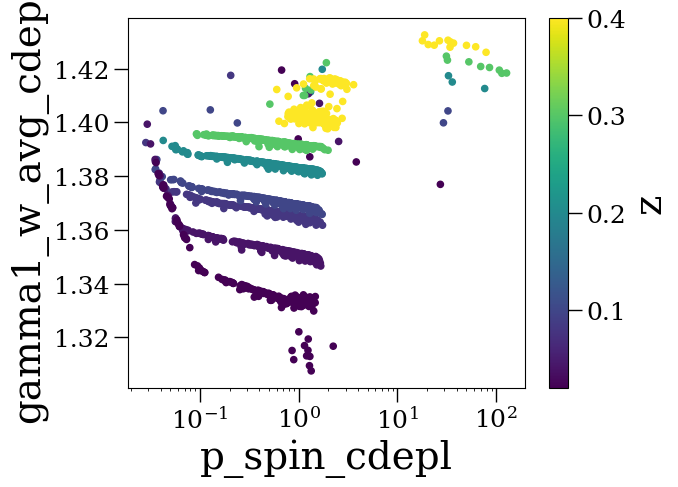

In [17]:
fig, ax = plt.subplots()
suc_che_df.plot.scatter(y='gamma1_w_avg_cdepl', x='p_spin_cdepl', c='z', ax=ax)
ax.set_xscale('log')

In [18]:
odepl_df = suc_che_df[suc_che_df.is_O_depleted].copy()

In [19]:
suc_che_df.z.unique()

array([0.08, 0.2 , 0.1 , 0.04, 0.02, 0.3 , 0.4 ])

In [20]:
odepl_df[odepl_df.z == 0.1]

,z_key,m_zams,m_wr0,m_wr1,m_tams,m_tahems,m_cdepl,m_odepl,m_f,m_c_zams,m_c_wr0,m_c_wr1,m_c_tams,m_c_tahems,m_c_cdepl,m_c_odepl,m_c_f,inertia_zams,inertia_wr0,inertia_wr1,inertia_tams,inertia_tahems,inertia_cdepl,inertia_odepl,inertia_f,p_spin_zams,p_spin_wr0,p_spin_wr1,p_spin_tams,p_spin_tahems,p_spin_cdepl,p_spin_odepl,p_spin_f,r_zams,r_wr0,r_wr1,r_tams,r_tahems,r_cdepl,r_odepl,r_f,r_c_zams,r_c_wr0,r_c_wr1,r_c_tams,r_c_tahems,r_c_cdepl,r_c_odepl,r_c_f,log_rho_c_zams,log_rho_c_wr0,log_rho_c_wr1,log_rho_c_tams,log_rho_c_tahems,log_rho_c_cdepl,log_rho_c_odepl,log_rho_c_f,log_j_zams,log_j_wr0,log_j_wr1,log_j_tams,log_j_tahems,log_j_cdepl,log_j_odepl,log_j_f,p_orb_zams,p_orb_wr0,p_orb_wr1,p_orb_tams,p_orb_tahems,p_orb_cdepl,p_orb_odepl,p_orb_f,log_t_d,temperature_center_zams,temperature_center_wr0,temperature_center_wr1,temperature_center_tams,temperature_center_tahems,temperature_center_cdepl,temperature_center_odepl,temperature_center_f,gamma1_center_zams,gamma1_center_wr0,gamma1_center_wr1,gamma1_center_tams,gamma1_center_tahems,gamma1_center_cdepl,gamma1_center_odepl,gamma1_center_f,gamma1_w_avg_zams,gamma1_w_avg_wr0,gamma1_w_avg_wr1,gamma1_w_avg_tams,gamma1_w_avg_tahems,gamma1_w_avg_cdepl,gamma1_w_avg_odepl,gamma1_w_avg_f,is_che,is_crit_at_zams,is_merger_at_zams,is_l2of_at_zams,is_He_depleted,is_half_C_depleted,is_C_depleted,is_O_depleted,is_crash,z
2695,0.1000,80.0,79.291928,55.289169,43.487064,33.47627,33.417166,33.416511,33.416511,59.33493,59.33493,37.696841,32.988496,28.476646,0.000003,1.764614,1.764614,9.680053e+57,9.680053e+57,3.198870e+57,1.016146e+57,6.151019e+55,4.904620e+54,1.218336e+55,1.218336e+55,0.9,1.05299,13.47588,9.796051,0.858446,0.121711,0.186838,0.174399,10.471253,10.471253,9.072916,5.365848,1.602317,0.638747,1.059139,1.059139,4.862187,4.862187,3.428926,1.816522,0.582758,0.00027,0.01173,0.01173,-0.667795,-0.667795,-0.423386,0.426897,1.705609,5.377644,5.974768,5.974768,53.395531,53.395531,52.496552,52.434645,52.06292,52.059465,52.059663,52.059663,1.121059,1.121059,2.723158,3.03283,5.117348,5.136914,5.137114,5.137114,10.130198,4.996170e+07,4.996170e+07,5.926186e+07,1.008944e+08,3.216418e+08,1.327480e+09,2.489626e+09,2.489626e+09,1.422885,1.422885,1.406579,1.403678,1.389506,1.40122,1.387695,1.387695,1.430332,1.430332,1.411824,1.408738,1.394808,1.374842,1.376436,1.376436,True,False,False,False,True,True,True,True,False,0.1


Text(20, 1.3363333333333332, '$\\Gamma_1$ = 4/3')

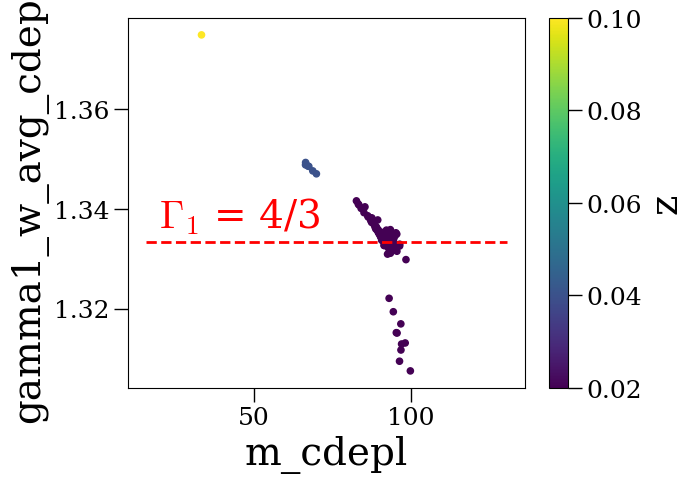

In [21]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_O_depleted)].plot.scatter(x='m_cdepl', y='gamma1_w_avg_cdepl', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_cdepl'].min(), xmax=suc_che_df['m_cdepl'].max(), colors='r', linestyles='dashed')
ax.text(20, 4/3+0.003, '$\\Gamma_1$ = 4/3', color='r')

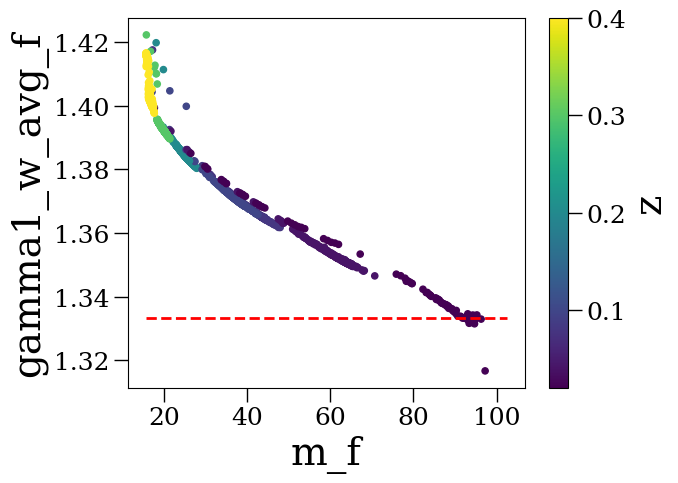

In [22]:
fig, ax = plt.subplots()
suc_che_df[(suc_che_df.is_C_depleted) & (~suc_che_df.is_O_depleted)].plot.scatter(x='m_f', y='gamma1_w_avg_f', c='z', colormap='viridis', ax=ax)
ax.hlines(4/3, xmin=suc_che_df['m_f'].min(), xmax=suc_che_df['m_f'].max(), colors='r', linestyles='dashed')

<Axes: xlabel='m_f', ylabel='z'>

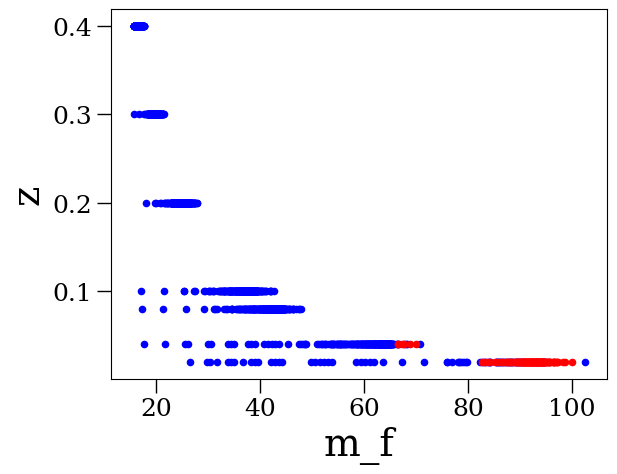

In [23]:
fig, ax = plt.subplots()
suc_che_df[suc_che_df.gamma1_w_avg_f > 4/3].plot.scatter(x='m_f', y='z', color='b', ax=ax)
suc_che_df[suc_che_df.gamma1_w_avg_f <= 4/3].plot.scatter(x='m_f', y='z', color='r', ax=ax)

## Core masses and PI threshold

Are our stars generally naked He cores? CO cores? What can we say, or implement from past work, in terms of the core threshold for PI?

In [37]:
pd.set_option('display.max_columns', None)

In [42]:
print(list(core_props_df.columns))

['z_key', 'm_zams', 'm_wr0', 'm_wr1', 'm_tams', 'm_tahems', 'm_cdepl', 'm_odepl', 'm_f', 'm_c_zams', 'm_c_wr0', 'm_c_wr1', 'm_c_tams', 'm_c_tahems', 'm_c_cdepl', 'm_c_odepl', 'm_c_f', 'inertia_zams', 'inertia_wr0', 'inertia_wr1', 'inertia_tams', 'inertia_tahems', 'inertia_cdepl', 'inertia_odepl', 'inertia_f', 'p_spin_zams', 'p_spin_wr0', 'p_spin_wr1', 'p_spin_tams', 'p_spin_tahems', 'p_spin_cdepl', 'p_spin_odepl', 'p_spin_f', 'r_zams', 'r_wr0', 'r_wr1', 'r_tams', 'r_tahems', 'r_cdepl', 'r_odepl', 'r_f', 'r_c_zams', 'r_c_wr0', 'r_c_wr1', 'r_c_tams', 'r_c_tahems', 'r_c_cdepl', 'r_c_odepl', 'r_c_f', 'log_rho_c_zams', 'log_rho_c_wr0', 'log_rho_c_wr1', 'log_rho_c_tams', 'log_rho_c_tahems', 'log_rho_c_cdepl', 'log_rho_c_odepl', 'log_rho_c_f', 'log_j_zams', 'log_j_wr0', 'log_j_wr1', 'log_j_tams', 'log_j_tahems', 'log_j_cdepl', 'log_j_odepl', 'log_j_f', 'p_orb_zams', 'p_orb_wr0', 'p_orb_wr1', 'p_orb_tams', 'p_orb_tahems', 'p_orb_cdepl', 'p_orb_odepl', 'p_orb_f', 'log_t_d', 'temperature_center_

In [43]:
work_df = core_props_df.copy()

In [47]:
work_df['m_mc_delta_zams'] = work_df.m_zams - work_df.m_c_zams
work_df['m_mc_delta_wr0'] = work_df.m_wr0 - work_df.m_c_wr0
work_df['m_mc_delta_wr1'] = work_df.m_wr1 - work_df.m_c_wr1
work_df['m_mc_delta_tams'] = work_df.m_tams - work_df.m_c_tams
work_df['m_mc_delta_tahems'] = work_df.m_tahems - work_df.m_c_tahems
work_df['m_mc_delta_cdepl'] = work_df.m_cdepl - work_df.m_c_cdepl
work_df['m_mc_delta_odepl'] = work_df.m_odepl - work_df.m_c_odepl

In [57]:
work_df.z_key.unique()

array(['0.0800', '0.2000', '0.1000', '0.0400', '0.0200', '0.3000',
       '0.4000'], dtype=object)

<Axes: xlabel='m_cdepl', ylabel='gamma1_w_avg_cdepl'>

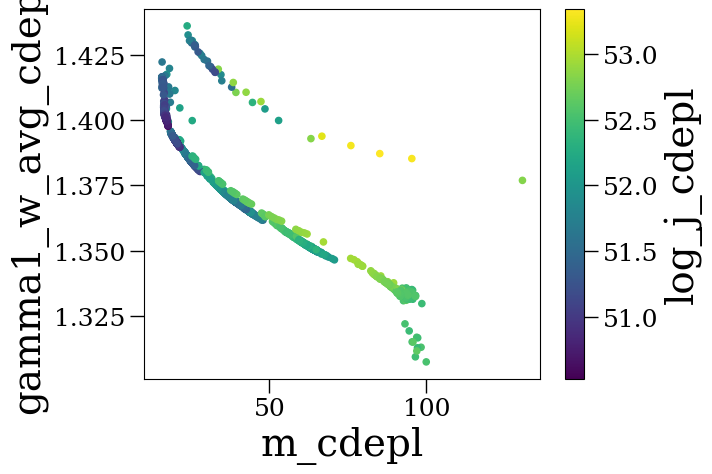

In [55]:
stage = 'cdepl'
work_df.plot.scatter(x=f'm_{stage}', y=f'gamma1_w_avg_{stage}', c=f'log_j_{stage}', colormap='viridis')